# Relationship Testing


Hypotheses from the [Analysis Design](a1_analysis_design.ipynb) section:
> Students who drink alcohol more frequently during the week are associated with worse grades.

> Students who have family support at home are associated with better final grades

> Better previous grades will be associated with better final grades.

> Students who have more free time are associated with better final grades, but this will vary by sex.

> Students with larger families can be identified by their final grade in portuguese


Relevant variables:

- Grades: Maths initial mG1, Maths final mG3, Portuguese initial pG1, Portuguese final pG3 - variable types - discrete numeric
- Weekday alcohol consumption: Dalc - ordinal categorical 
- Support at home: famsup - dichotomous

The final maths and portugese grades mG3 and pG3 are the dependent variables.
The initial maths and portuguese grades (mG1, pG1),  weekday alcohol frequency (Dalc), and Family support (famsup) are the independent variables.

Assumptions will be checked so that appropriate tests can be selected.

To test the hypothesis that students who have better initial grades will have better final grades we will compare the initial and final grades in both subjects. i.e. mG1 with mG3, and pG1 with pG3.

To test the hypothesis that students who drink more often during the weekend are associated with worse grades, we will compare the frequency of weekday alcohol consumption with the final grades.

To test the hypothesis that students who have family support do better we will compare this with the final grades.



In [17]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import math
import seaborn as sns

import utils

The variables we will be considering are: 
- the initial and final grades in mathematics and portuguese (mG1, mG3, pG1, pG3)
- the frequency of weekday alcohol consumption (Dalc)
- the existence of family support for the student (famsup)


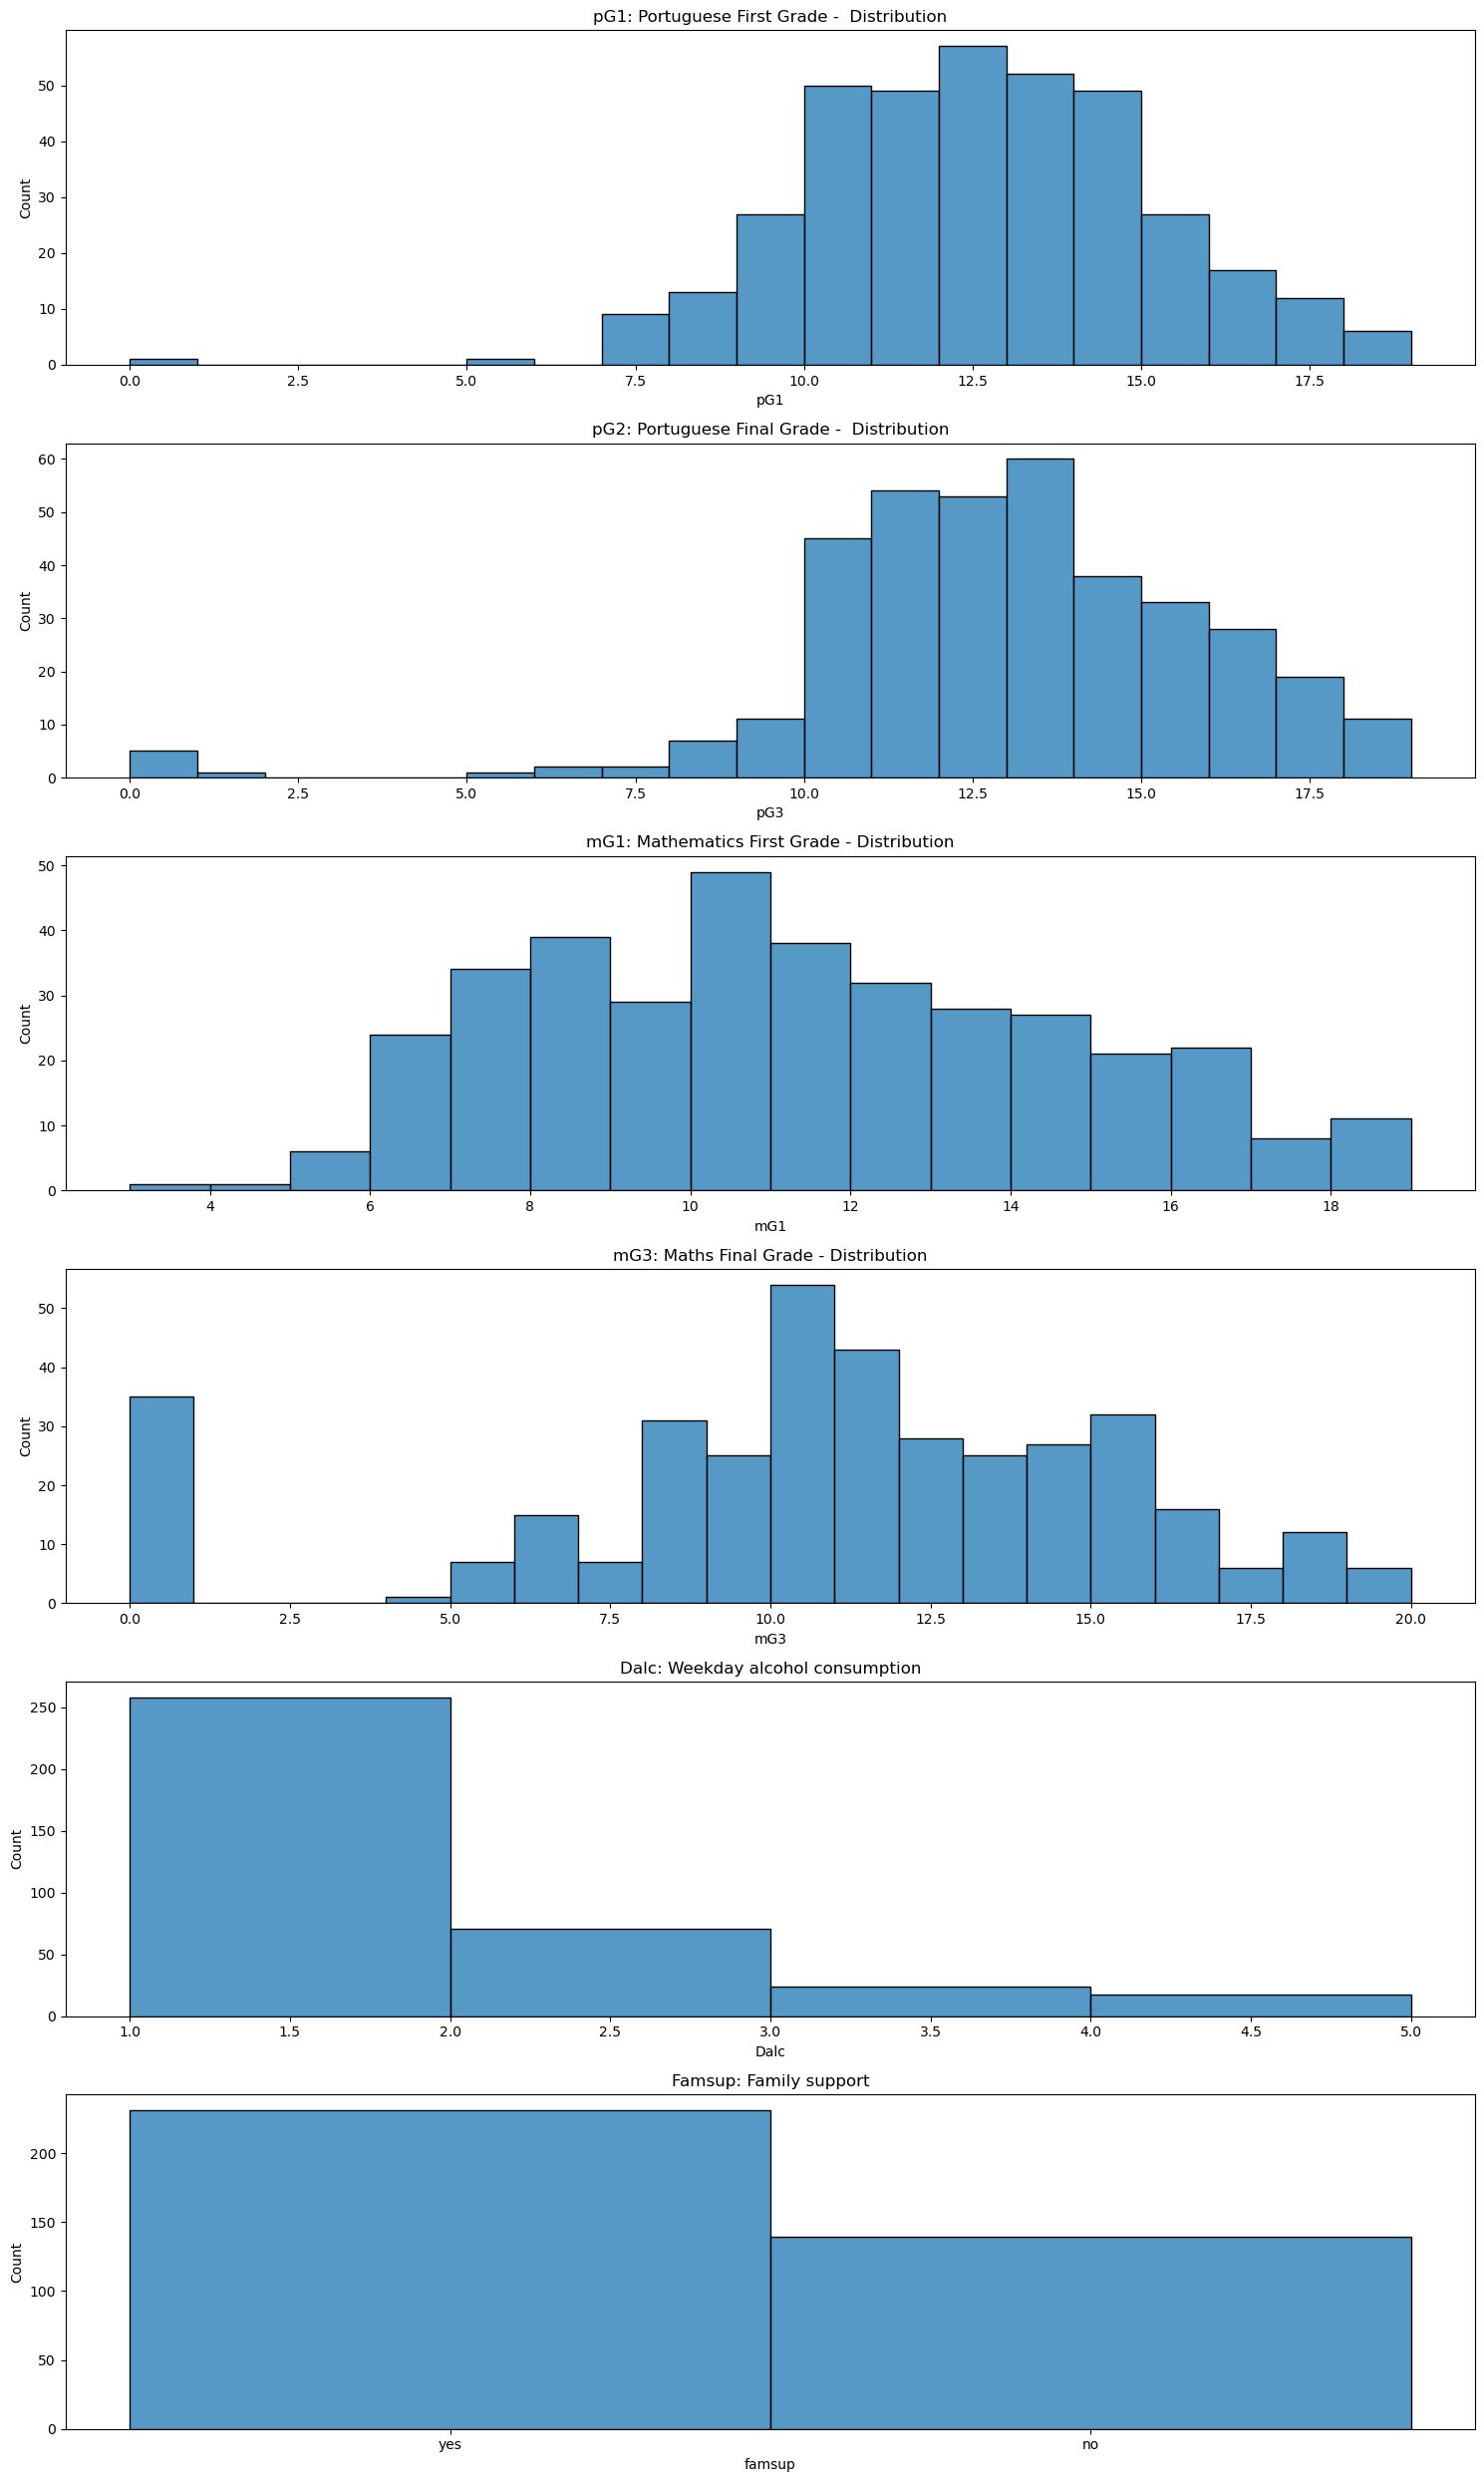

In [18]:
df = pd.read_csv("prepared_dataset.csv") # load the csv file prepared in a2_data_description.ipynb
fig, ax = plt.subplots(6)
fig.set_size_inches(15,25)

sns.histplot(data=df, x="pG1", binwidth=1, stat='count', ax=ax[0])
ax[0].set_title("pG1: Portuguese First Grade -  Distribution")

sns.histplot(data=df, x="pG3", binwidth=1, stat='count', ax=ax[1])
ax[1].set_title("pG2: Portuguese Final Grade -  Distribution")

sns.histplot(data=df, x="mG1", binwidth=1,stat='count', ax=ax[2])
ax[2].set_title("mG1: Mathematics First Grade - Distribution")

sns.histplot(data=df, x="mG3", binwidth=1, stat='count', ax=ax[3])
ax[3].set_title("mG3: Maths Final Grade - Distribution")

sns.histplot(data=df, x="Dalc", binwidth=1, stat='count', ax=ax[4])
ax[4].set_title("Dalc: Weekday alcohol consumption")

sns.histplot(data=df, x="famsup", binwidth=1,stat='count', ax=ax[5])
ax[5].set_title("Famsup: Family support")

plt.tight_layout()

By plotting the distributions we can see that the numeric grade variables for maths and portuguese (mg1, mG3, pG1, pG3) appear as though they may be normally distributed. 

However, we already know from the tests we performed in the [Assumption Testing](a4_assumption_testing.ipynb) section that the final maths and portuguese grades are not normally distributed. However, we still need to check assumptions for the initial maths and portuguese grades.

The categorical variable of Daily alcohol consumption, *Dalc* and the dichotomous variable for whether or not a student had support from their family, *famsup*, are clearly not normally distributed. 

## Assumption Testing

#### Assumption Tests for the numeric variables mG1, mG3, pG1, pG3

These 4 numeric variables look like they may have normal distributions.

To confirm, we will perform visual tests of normality and check the skewness and kurtosis to give an indication of the tests we can use to compare the relationships.

#### Visual Inspection of normality

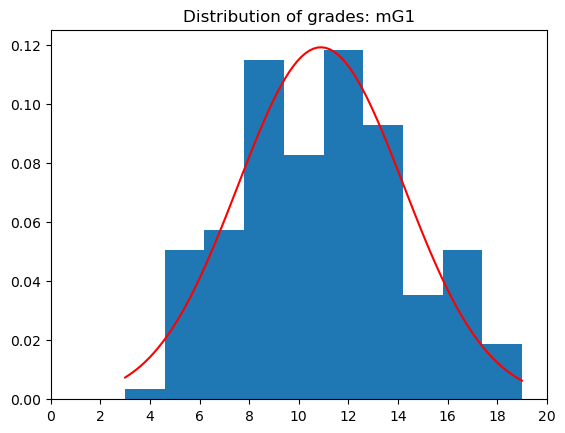

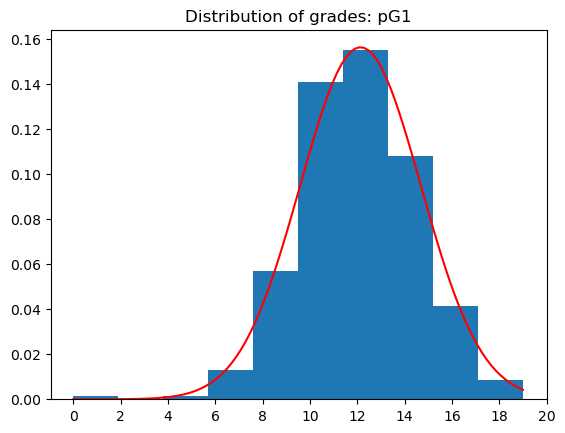

In [19]:
# plot the histogram  against a normal distribution PDF

utils.plot_hist_and_norm_pdf(df.mG1, standardize=False)
plt.title("Distribution of grades: mG1")
plt.xticks(np.arange(0, 20+1, 2))
plt.show()


utils.plot_hist_and_norm_pdf(df.pG1, standardize=False)
plt.title("Distribution of grades: pG1")
plt.xticks(np.arange(0, 20+1, 2))
plt.show()


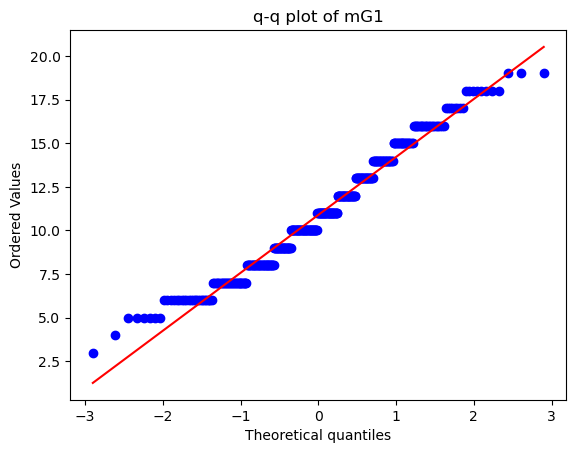

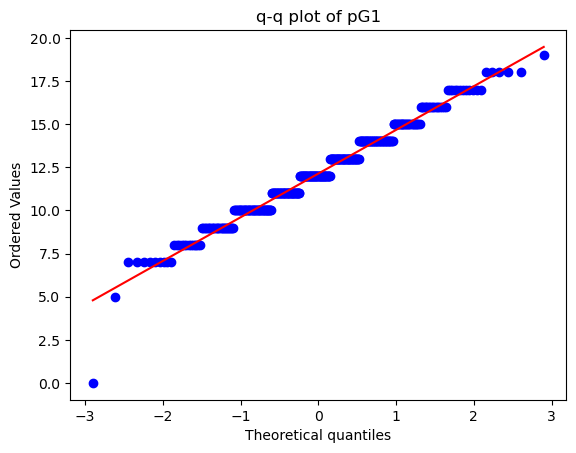

In [20]:
#QQplot of mG1, pG1,
ss.probplot(df.mG1, plot=plt)
plt.title("q-q plot of mG1")
plt.show()



ss.probplot(df.pG1, plot=plt)
plt.title("q-q plot of pG1")
plt.show()



The distribution of the initial maths grade does not appear to be normal. There are a number of outliers and a slight curve to the line on the q-q plot.

The inital portuguese grade pG1 appears to be close to normal, however there are is an outlier.

To confirm we will check what percentage of each distribution lies over 2 standard deviations from the mean. 

##### Spread of values

In [21]:
# Outlier test
print("mG1 % outliers over 2SD", utils.pc_over_2sd(df.mG1))
print("pG1 % outliers over 2SD", utils.pc_over_2sd(df.pG1))

mG1 % outliers over 2SD 3.5135135135135136
pG1 % outliers over 2SD 4.594594594594595


Neither of the variables (mG1, pG1) checked have more than 5% of their values over 2 standard deviations from the mean. For this reason, they can both can be considered normal based on the outlier test.

##### Skewness and Kurtosis

In [30]:
mg1_skew_z =round(ss.skew(df.mG1)/utils.se_skew(len(df.mG1)), 3)
mg1_kurtosis_z = round(ss.kurtosis(df.mG1, fisher=True)/utils.se_kurt(len(df.mG1)), 3)
print("mG1 skewness and kurtosis", mg1_skew_z, ",", mg1_kurtosis_z)



pg1_skew_z =round(ss.skew(df.pG1)/utils.se_skew(len(df.pG1)), 3)
pg1_kurtosis_z = round(ss.kurtosis(df.pG1, fisher=True)/utils.se_kurt(len(df.pG1)), 3)
print("pG1 skewness and kurtosis", pg1_skew_z, ",", pg1_kurtosis_z)




mG1 skewness and kurtosis 2.152 , -2.713
pG1 skewness and kurtosis -1.284 , 3.122


The skewness and kurtosis values suggest that at a 95% confidence level the first maths grade (mG1) has skewness outside the $\pm$ 1.96 range, but the first portuguese grade (pG1) was within the 95% level of confidence.

The kurtosis for both variables is outside the $\pm$ 1.96 range.

These results suggest non-normality for both of the grade related variables.

#### Shapiro-Wilk's and Kolmogorov-Smirnov tests

In [31]:
print("mG1: \n", ss.shapiro(df.mG1), "\n", ss.ks_1samp(df.mG1, ss.norm.cdf))
#print("\nmG3: \n", ss.shapiro(df.mG3), "\n", ss.ks_1samp(df.mG3, ss.norm.cdf))
print("\npG1: \n", ss.shapiro(df.pG1), "\n", ss.ks_1samp(df.pG1, ss.norm.cdf))
#print("\npG3: \n", ss.shapiro(df.pG3), "\n", ss.ks_1samp(df.pG3, ss.norm.cdf))

mG1: 
 ShapiroResult(statistic=0.9732078313827515, pvalue=2.414074742773664e-06) 
 KstestResult(statistic=0.9986501019683699, pvalue=0.0, statistic_location=3, statistic_sign=-1)

pG1: 
 ShapiroResult(statistic=0.9773955941200256, pvalue=1.5285902918549255e-05) 
 KstestResult(statistic=0.9972970106457254, pvalue=0.0, statistic_location=5, statistic_sign=-1)


The low p-values of the Shapiro-Wilk's (*p*<.001) and Kolmogorov-Smirnov (*p*<.001) tests for the variables suggests that the distributions are not normal. 

Based on the assumption tests performed here on the initial grades, and in the [Assumption Testing](a4_assumption_testing.ipynb) section on the final grades, the distributions of the initial and final maths and portuguese grades (mG1, mG3, pG1 and pG3) can not considered normal enough for parametric relationship tests.

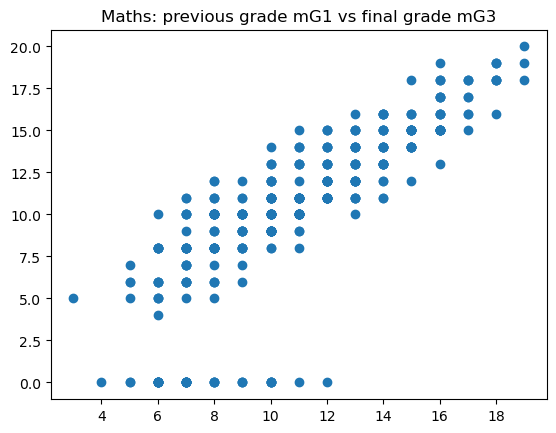

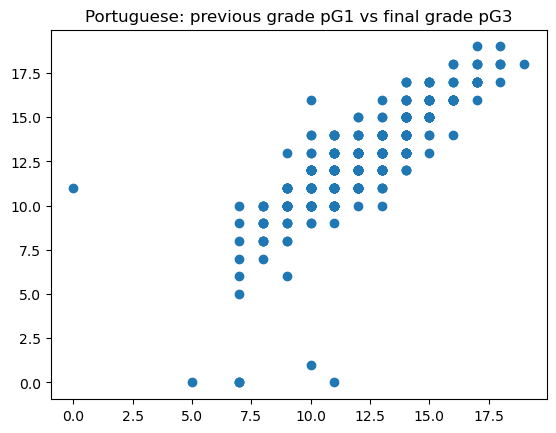

In [24]:
plt.scatter(df["mG1"], df['mG3'])
plt.title("Maths: previous grade mG1 vs final grade mG3")
plt.show()


plt.scatter(df["pG1"], df['pG3'])
plt.title("Portuguese: previous grade pG1 vs final grade pG3")
plt.show()

The shape of both scatter plots indicates a possible linear relationship between the previous grade in that subject and the final grade recieved by the student.

## Relationship Testing

### Test 1: 

Testing the relationship between the first and final grades for Maths (mG1 and mG3), and also Portuguese (pG1 and pG3).

Basis for the test:

 > "Better previous grades will be associated with better final grades."

 From our assumption testing, we know that the grade distributions can not be considered normal. 


 Since we have 4 numeric variables, and none meet the assumptions of normality we can perform Spearman's rank test to investigate the relationship between the first and final Maths grades and Portuguese grades.



#### Spearman's rank correlation coefficient
Comparing the relationship between the first and final maths grades (mG1 + mG3), and the first and final portuguese grades (pG1 + pG3) to see if previous grades in maths and portuguese are related to final grades in those subjects.

In [25]:
rho, p_value = ss.spearmanr(df['mG1'], df['mG3'])
print("Spearman's rho: mG1 and mG3")
print("rho: ", rho)
print("p: ", p_value)

print()

rho, p_value = ss.spearmanr(df['pG1'], df['pG3'])
print("Spearman's rho: pG1 and pG3")
print("rho: ", rho)
print("p: ", p_value)

Spearman's rho: mG1 and mG3
rho:  0.8784214778813548
p:  4.637180695649304e-120

Spearman's rho: pG1 and pG3
rho:  0.8652030145780082
p:  2.2696914954415716e-112


The Spearman's rho correlation between mG1 and mG3 showed a strong positive correlation,  $\rho$ =.88, *p* <.001.

Similarly, the correlation between pG1 and pG3 also showed a strong positive correlation, $\rho$ =.87, *p* <.001.

Comparing both $\rho$ values to the reference effect size magnitudes
[\[1\]](https://imaging.mrc-cbu.cam.ac.uk/statswiki/FAQ/effectSize) shows that correlation between the Maths grades (mG1, mG3) and also between the Portuguese grades(pG1, pG3), have a large effect size with both *rho* values well above 0.5.

In conclusion, for both Mathematics and Portuguese, strong positive correlations were observed between initial and final grades (mG1 and mG3: $\rho = .88$, $p < .001$; pG1 and pG3: $\rho = .87$, $p < .001$), both indicating a large effect size and suggesting that previous grades are good predictors of final grade results in these subjects.

### Test 2: 

Testing the relationship between the frequency of alcohol consumption during the week vs the final grade received.

Basis for the test:
> Students who drink alcohol more frequently during the week are associated with worse grades.

Dalc is the ordinal categorical variable of how often students consume alcohol on weekdays, represented with a number from 1 to 5, where 1 is very low, and 5 is very high.

Since we have an ordinal independent variable for the frequency of weekday alcohol consumption (Dalc), and non-normally distributed final grade dependent variables (mG3, pG3), we can use Kendall's Tau test to check the relationship between the frequency of alcohol consumption during the week, and the maths and portuguese final grades.

#### Kendall's Tau test

In [26]:
# Apply the Kendall Tau test to the listsabs
tau, p = ss.kendalltau(df['Dalc'], df['mG3'])
print("Dalc vs mG3:")
print("tau = " + str(tau))
print("p = " + str(p))

print()

tau, p = ss.kendalltau(df['Dalc'], df['pG3'])
print("Dalc vs pG3:")
print("tau = " + str(tau))
print("p = " + str(p))

Dalc vs mG3:
tau = -0.08286475481380369
p = 0.05127651824684464

Dalc vs pG3:
tau = -0.2138002451147233
p = 6.772884276493267e-07


Kendall's tau test indicated that the relationship between weekday alcohol consumption (Dalc) and the  final Maths grade (mG3) had a weak negative correlation (tau =-0.08, p=.05). 

For the relationship between weekday alcohol consumption and the Portuguese final grade, a significant negative correlation was found (tau=-0.21, p<.001).

In terms of effect size,  Dalc vs mG3 (tau=-0.08) has a small effect (<0.1).
Dalc vs pG3 has a medium effect (<0.3)


In summary, looking at weekday alcohol consumption (Dalc), Kendall's tau test revealed a weak negative correlation with final Mathematics grades ($\tau = -0.08$, $p = .05$, small effect size) and a significant negative correlation with final Portuguese grades ($\tau = -0.21$, $p < .001$, medium effect size), suggesting that increased alcohol consumption is associated with lower grades, particularly in Portuguese.

#### Test 3: Mann-Whitney U-test

Testing the relationship between students who have support at home and their final grades in maths and portuguese.


>Students who have a family support at home are associated with better final grades

Family support is a dichotomous categorical variable. Values are either "yes", if a student receives support from family at home, or "no" if they do not. 

Our grade distributions are not normal and therefore a non-parametric test is required.

To compare the dichotomous family support variable to the numeric grades mG3 and pG3 we can use the Mann-Whitney U-test.
 
H0_maths: The final maths grade is equal between students with and without family support.

H0_portuguese: The final portuguese grade is equal between students with and without family support.


In [27]:
# mann-whitney u test comparing famsup to mG3, pG3

# sample size > 30
print("Sample size: ", len(df))
print()
print("mG3")
yes_fam_sup_mG3 = df[df['famsup'] == 'yes']['mG3']  #students with family support = "yes"
no_fam_sup_mG3 = df[df['famsup'] == 'no']['mG3'] #students without family support = "no"
u_stat_mG3, p = ss.mannwhitneyu(yes_fam_sup_mG3, no_fam_sup_mG3, alternative='two-sided')

print(f'Mann-Whitney U stat = {u_stat_mG3}')
print(f'p = {p}')

print()
print("pG3")
yes_fam_sup_pG3 = df[df['famsup'] == 'yes']['pG3']  #grades of students with family support = "yes"
no_fam_sup_pG3 = df[df['famsup'] == 'no']['pG3'] #grades ofstudents without family support = "no"
u_stat_pG3, p = ss.mannwhitneyu(yes_fam_sup_pG3, no_fam_sup_pG3, alternative='two-sided')

print(f'Mann-Whitney U stat = {u_stat_pG3}')
print(f'p = {p}')


Sample size:  370

mG3
Mann-Whitney U stat = 14916.0
p = 0.25138225523974156

pG3
Mann-Whitney U stat = 17381.0
p = 0.18004054758761556


Neither of the null hypotheses that ***"The final maths grade rank sum is equal between students with and without family support."***, and ***"The final portuguese grade rank sum is equal between students with and without family support"*** can be rejected based on the U statistic and p-value (*U* = 14916, *p* = .25) as the p value is greater than the .05 significance level.

For both mG3 and pG3 the distributions of grades for students with family support are not significantly different from students without family support.

In [28]:
# effect size 

# effect size of the groups with and without family support in terms of final maths grades
print("mG3:")
r = utils.mwu_es_r(yes_fam_sup_mG3, no_fam_sup_mG3)
utils.print_stat("r", r)

auc = utils.mwu_es_auc(yes_fam_sup_mG3, no_fam_sup_mG3)
utils.print_stat("AUC", auc)

print()

# effect size of the groups with and without family support in terms of final portuguese grades
print("pG3:")
r = utils.mwu_es_r(yes_fam_sup_pG3, no_fam_sup_pG3)
utils.print_stat("r", r)

auc = utils.mwu_es_auc(yes_fam_sup_pG3, no_fam_sup_pG3)
utils.print_stat("AUC", auc)

mG3:
r: 0.07091469681397744
AUC: 0.4645426515930113

pG3:
r: -0.08262480924351445
AUC: 0.5413124046217572


For mG3 the effect size (*r* = .07, *p* = ) shows a small effect on the final maths grade when student have family support. The area under the curve value (*AUC* = .46) tells us that the probability of the mG3 grade being higher for students with **no** family support is 46%. This means that there is not much difference in the final maths grades of the groups with and without family support.

For pG3, the effect size (*r* = .08) also shows a small effect on the final grade when students have family support.
The area under the curve value (*AUC* = .54) tells us that for the final Portuguese grade, the probability of students with family support having higher grades than students without support is 54%, again not showing much difference between the two groups.


In summary, using the Mann-Whitney U test to examine the impact of family support on final grades, no significant differences were found between students with and without family support in either Mathematics ($U = 14916$, $p = .25$, $r = .07$) or Portuguese ($U = 17381$, $p = .18$, $r = .08$), indicating only a small effect of family support on final grade outcomes in both subjects.


### Conclusions 
Three relationship tests were performed to investigate the relationships between variables relating to the initial hypotheses.

1. A Spearman's rank correlation test was performed to compare the relationship between the initial and final grades to see if better initial grades were related to better final grades. The results of this test showed a highly significant relationship for grades in both subjects.

2. Kendall's Tau test was performed to compare the weekday alcohol consumption with the final grades to see if the frequency of weekday drinking is associated with the final grade. This test showed that as weekday alcohol consumption increases the final grade score decreases. This effect was stronger for grades in Portuguese, with a medium effect size, than maths, where the effect was small.

3. A Mann Whitney U test was performed on the groups of students with and without family support to see if the final grades would differ between the two groups. No significant differences were found to exist between the groups suggesting that family support is not very related to a student's final grade in Maths or Portuguese.